# Übung 7

**Gruppenname:**

*TKKR*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.


2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...
... werden wir die logistische Regression implementieren und anwenden (Übung 7.1 und 7.2). Daneben werden wir noch einmal Zusammenhänge zwischen Klassifikation, linearer Regression und logistischer Regression (Übung 7.3) sowie zwischen PLA und dem stochastischen Gradientenabstieg (Übung 7.4) beleuchten.

### 7.1 Zulassungskommission (Logistische Regression, Gradientenabstieg)
Eine Kommission an einer Hochschule hat in den vergangenen Jahren Bachelorabsolventen, die sich für einen Masterstudiengang bewarben, nach eingehender Prüfung zugelassen oder abgelehnt. Die Hochschulverwaltung überlegt, die durch die Kommissionsarbeit gebundenen Arbeitsressourcen freizusetzen und die Kommission von ihrer Arbeit zu entbinden. Die Wahrscheinlichkeit, mit der die Kommission die Zulassung zum Masterstudium für eine Bewerberin / einen Bewerber empfohlen hätte, soll mithilfe von Machine Learning und historischer Daten (nämlich dem Punkteergebnis von zwei Klausuren jedes Bewerbers sowie der damaligen Entscheidung der Kommission) vorhergesagt werden.

**Daten:**

Die Daten enthalten die Punktzahlen zweier Abschlussklausuren (Feature 1 (Spalte 1) und Feature 2 (Spalte 2)), die ein Bewerber / eine Bewerberin in ihrem Bachelorstudium erzielte, sowie die Entscheidung (Label (3. Spalte)) der Kommission, ob der Bewerber zum Masterstudium zugelassen wurde (+1) oder abgelehnt wurde (0). Und bevor Sie fragen: Dies ist ein ausgedachter Fall und kein Fall der FH Aachen.

**Ihre Aufgaben**

(1) Importieren Sie zunächst die Daten, indem Sie die unten angegebene Codezelle ausführen.

In [30]:
import numpy as np
from matplotlib import pyplot as plt
import requests
%matplotlib inline

# Sie finden diese Daten auch zum Download unter: https://data.bialonski.de/ml/admission-data.txt
data = np.loadtxt('https://data.bialonski.de/ml/admission-data.txt', delimiter=',')

(2) Wir müssen zunächst die Daten aufbereiten. Dazu gehen Sie bitte wie folgt vor:

1. Definieren Sie ein Array `X`, welches die Daten der beiden Features enthalten soll.
2. Definieren Sie einen Vektor `y`, welcher die Labels enthalten soll.
3. Reskalieren Sie die Features in `X` auf den Wertebereich von 0 bis 1.
4. Fügen Sie dem Feature-Array `X` eine neue zusätzliche Spalte hinzu (Spalte "0"), die nur Einsen enthält. Diese Spalte bzw. Dimension wird für den Bias-Term benötigt (wie im Kontext der linearen Regression oder im Kontext des Perzeptrons).
5. Vergleichen Sie die Werte, die die Labels in Ihren Daten annehmen können, mit den Werten, die in der Vorlesung genannt wurden. Formen Sie dann die Einträge im Label-Vektor `y` so um, dass sie der Konvention der Vorlesung entsprechen.


* Hinweis: Wenn Sie die oben genannten Umformungen nicht umsetzen, werden Sie auf Schwierigkeiten in den nachfolgenden Schritten stoßen. Schließen Sie daher diesen Aufgabenteil ab, bevor Sie fortfahren.

In [31]:
X = data[:, :2].copy()
y = data[:, 2].copy()
X /= 100
X = np.c_[np.ones(X.shape[0]), X]
print(X.max(0))
print(X.min(0))
y = y * 2 - 1
print(np.unique(y))

[1.         0.99827858 0.98869436]
[1.         0.30058822 0.30603263]
[-1.  1.]


(3) Tragen Sie in einem Scatterplot Feature 1 gegen Feature 2 auf. Markieren Sie über Farbe oder Symbole, ob die Studienanwärter zum Masterstudium zugelassen wurden ($y=1$) oder nicht ($y\neq1$).

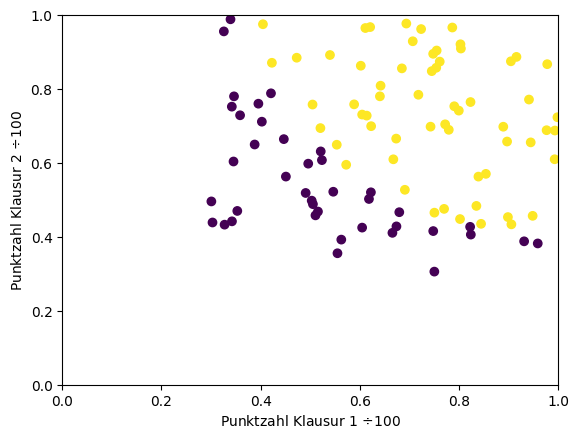

In [32]:
plt.scatter(X[:, 1], X[:, 2], c=y)
plt.xlabel("Punktzahl Klausur 1 $\\div 100$")
plt.ylabel("Punktzahl Klausur 2 $\\div 100$")
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

(4) Implementieren Sie eine Funktion `gradient`, die einen Gewichtsvektor, Features und Labels entgegennimmt und den Gradientenvektor der logistischen Regression zurückgibt. Schlagen Sie in den entsprechenden Folien der Vorlesung nach. Erinnern Sie sich daran, dass jeder Feature-Vektor drei Komponenten ($x_0$, $x_1$, $x_2$) hat, wobei $x_0=1$ und $x_1$ sowie $x_2$ der Wert des ersten bzw. zweiten Features ist.

In [33]:
def gradient(w: np.ndarray, x: np.ndarray, y: np.ndarray) -> np.ndarray:
    n = y.shape[0]
    y_vect = y.copy()[:, np.newaxis]
    x_neg_pabs = -1 * y_vect * x
    sum_vect = x_neg_pabs / (1 + np.exp(y_vect * (x @ w)[:, np.newaxis]))
    return sum_vect.sum(0) / n

(5) Implementieren Sie eine Funktion `E_in`, die einen Gewichtsvektor $\mathbf{w}$, die Featurevektoren $\mathbf{x}$ sowie die Labels $\mathbf{y}$ entgegennimmt und Ihnen den Fehler $E_\text{in}(\mathbf{w})$ der logistischen Regression zurückgibt.

In [34]:
def E_in(w: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    n = y.shape[0]
    sum_vect = np.log(1 + np.exp(-1 * y * (x @ w)))
    return sum_vect.sum() / n

(6) Implementieren Sie den "Gradientenabstieg mit fixierter Lernrate" (Funktion `grad_descent`), wie Sie ihn in der Vorlesung kennengelernt haben. Vergegenwärtigen Sie sich, dass beim Gradientenabstieg die Gewichtsvektoren verändert werden, nicht aber die Daten ($\mathbf{x}$ und $\mathbf{y}$ bleiben unverändert). Bauen Sie zusätzlich ein, dass bei jedem Iterationsschritt $t$ der Fehler $E_\text{in}(\mathbf{w}(t))$ berechnet wird und am Ende - neben dem finalen Gewichtsvektor - auch sämtliche über die Iterationen hinweg erzielten Fehler als Vektor herausgegeben wird.

In [35]:
def grad_descent(x: np.ndarray, y: np.ndarray, nit: int, w: np.ndarray = None, n=0.1, eps=1e-8) -> tuple[np.ndarray, list]:
    errors = []
    if w is None:
        w = np.zeros(x.shape[1])
    else:
        w = w.copy()
    errors.append(E_in(w, x, y))
    for _ in range(nit):
        g_t = gradient(w, x, y)
        v = -g_t
        w += n * v
        err_curr = E_in(w, x, y)
        errors.append(err_curr)
        if err_curr < eps:
            break
    return w, errors

(7) Entscheiden Sie sich dafür, wie sie den Anfangsgewichtsvektor $\mathbf{w}(0)$ initialisieren wollen. Sie können beispielsweise die Komponenten von $\mathbf{w}(0)$ aus einer Standardnormalverteilung mit kleiner Varianz ziehen. Oder Sie können einmal ausprobieren, $\mathbf{w}(0) = \mathbf{0}$ zu setzen.

(8) Entscheiden Sie sich für Terminationskriterien und eine Lernrate $\eta$ für den Gradientenabstieg. Ausgangspunkt könnte beispielsweise eine Lernrate von $\eta = 0.1$ und einer Termination bei 400 Iterationen sein. Bitte experimentieren Sie aber im nächsten Schritt (Schritt 9) mit unterschiedlichen Werten (beispielsweise $\eta = 1$ und/oder einer Termination nach 5000 Schritten) und einer größeren oder kleinen Anzahl an Iterationen.

(9) Führen Sie einen Gradientenabstieg durch und visualisieren Sie den Fehler $E_\text{in}(t)$ über die Iterationsschritte $t$ hinweg.

0.20743871254686425


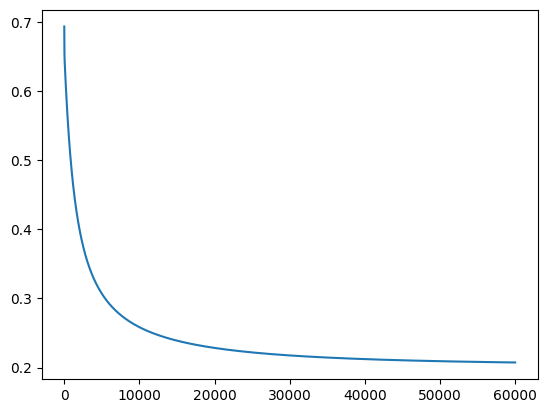

CPU times: total: 2.08 s
Wall time: 2.11 s


In [36]:
%%time
w_log, errs = grad_descent(X, y, 60000)
print(errs[-1])
plt.plot(errs)
plt.show()

0.2074362631369156


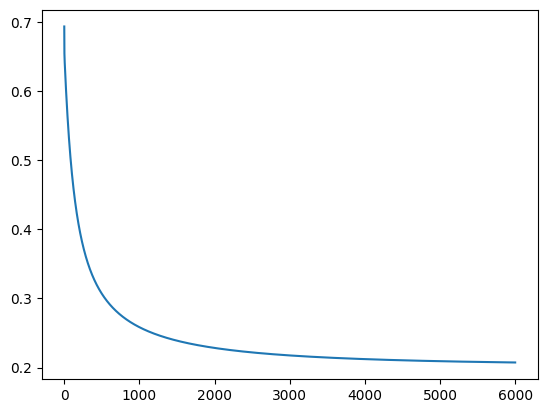

CPU times: total: 297 ms
Wall time: 297 ms


In [37]:
%%time
w_log, errs = grad_descent(X, y, 6000, n=1)
print(errs[-1])
plt.plot(errs)
plt.show()

In [38]:
w_init = np.random.normal(size=X.shape[1])
w_init

array([-0.28282283, -2.1880193 , -0.02708446])

0.2074633205801117


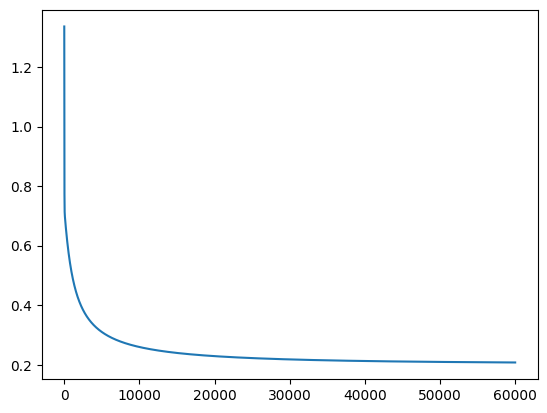

CPU times: total: 2.08 s
Wall time: 2.09 s


In [39]:
%%time
w_log, errs = grad_descent(X, y, 60000, w=w_init)
print(errs[-1])
plt.plot(errs)
plt.show()

0.2074608479135294


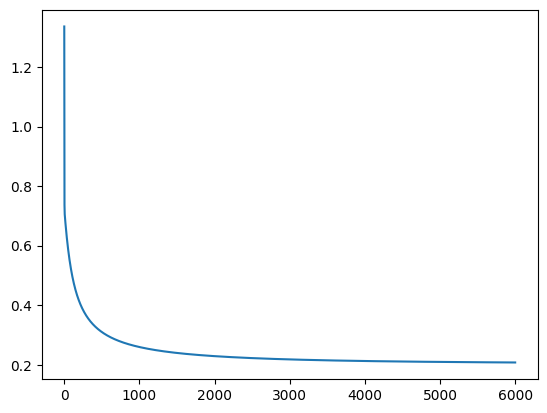

CPU times: total: 281 ms
Wall time: 292 ms


In [40]:
%%time
w_log, errs = grad_descent(X, y, 6000, n=1, w=w_init)
print(errs[-1])
plt.plot(errs)
plt.show()

(10) Nutzen Sie das finale Modell $g$ (spezifiziert durch den finalen Gewichtsvektor), um die Zulassungswahrscheinlichkeit $\left( g(\mathbf{x}) = \mathbb{P}[y=+1|\mathbf{x}] \right)$ für das Masterstudium eines Anwärters vorherzusagen, der folgende Ergebnisse in seinen zwei Abschlussklausuren erzielte: (Feature 1, Feature 2) = (0.45, 0.85). Schlagen Sie dazu in den Folien der Vorlesung nach, wie diese Wahrscheinlichkeit aus dem Gewichtsvektor und dem Featurevektor zu berechnen ist.

In [41]:
def g(w: np.ndarray, x: np.ndarray) -> np.ndarray:
    return 1.0 / (1 + np.exp(- x @ w))

In [42]:
print(g(w_log, np.array([1, 0.45, 0.85])))

0.7317170287399214


(11) Visualisieren Sie die Zulassungswahrscheinlichkeit für die Featureebene, die durch Feature 1 und 2 aufgespannt wird: Legen Sie dazu ein Grid durch den Feature-Raum, wobei Sie jedes der beiden Feature von $0$ bis $1$ in $0.01$er Schritten scannen, für jedes Wertepaar die Zulassungswahrscheinlichkeit berechnen, und im Anschluss daran visualisieren. `plt.imshow` kann Ihnen dabei helfen.

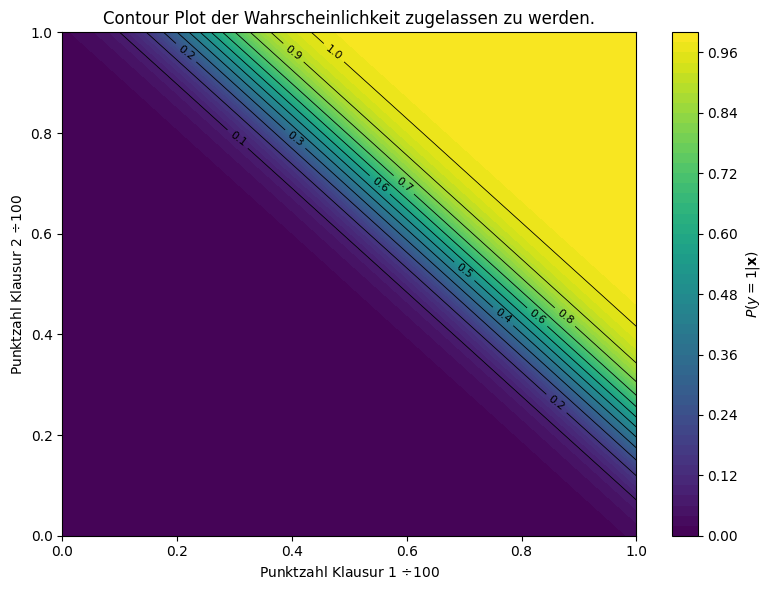

In [43]:
space = np.linspace(0.0, 1.0, 100)
grid_1, grid_2 = np.meshgrid(space, space)

x_grid = np.c_[np.ones(100 * 100), grid_1.ravel(), grid_2.ravel()]

probab = g(w_log, x_grid).reshape(100, 100)

plt.figure(figsize=(8, 6))
cf = plt.contourf(grid_1, grid_2, probab, levels=60, cmap='viridis')
cs = plt.contour(grid_1, grid_2, probab, levels=15, colors='k', linewidths=0.6)
plt.clabel(cs, inline=True, fontsize=8, fmt='%.1f')
plt.xlabel("Punktzahl Klausur 1 $\\div 100$")
plt.ylabel("Punktzahl Klausur 2 $\\div 100$")
plt.title('Contour Plot der Wahrscheinlichkeit zugelassen zu werden.')
plt.colorbar(cf, label='$P(y=1|\\mathbf{x})$')
plt.tight_layout()
plt.show()

### 7.2: Von logistischer Regression hin zur Klassifikation

* Zur Bearbeitung dieser Aufgabe müssen Sie bereits Aufgabe 7.1. gelöst haben.

* Diese Aufgabe ist eine Fortsetzung von Aufgabe 7.1. Sie ist separat von 7.1 aufgeführt, weil wir hier ein logistisches Regressionsproblem in ein Klassifikationsproblem überführen. Dies ist ein ganz typisches Vorgehen, das oft angewandt wird.

Wir werden jetzt unser logistisches *Regressions*modell aus Aufgabe 7.1. nutzen, um ein *Klassifikations*problem zu lösen: Welche Bachelorstudierenden sollten für das Masterstudium zugelassen werden?

Für diese Umwandlung in ein Klassifikationsproblem definieren wir einen Schwellwert $P_s$. Der Kandidat bzw. die Kandidatin wird zugelassen, sofern $\mathbb{P}[y=+1|\mathbf{x}] \geq P_s$. Wir wählen $P_s = 0.5$.

(1) Visualisieren Sie die Daten wie im Schritt (1) von Aufgabe 7.1. Passen Sie den Scatterplot an, sodass Sie zusätzlich (z.B. Farb- oder Symbolkodiert) darstellen, ob die Studierenden durch das Modell zugelassen würden ($\mathbb{P}[y=+1|\mathbf{x}] \geq P_s$) oder nicht. Dazu müssen Sie Ihr trainiertes Modell zur Vorhersage der Zulassungswahrscheinlichkeiten nutzen und den Schwellwert anwenden.

In [44]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

# Sie finden diese Daten auch zum Download unter: https://data.bialonski.de/ml/admission-data.txt
data = np.loadtxt('https://data.bialonski.de/ml/admission-data.txt', delimiter=',')

In [45]:
X = data[:, :2].copy()
y = data[:, 2].copy()
X /= 100
X = np.c_[np.ones(X.shape[0]), X]
print(X.max(0))
print(X.min(0))
y = y * 2 - 1
print(np.unique(y))

[1.         0.99827858 0.98869436]
[1.         0.30058822 0.30603263]
[-1.  1.]


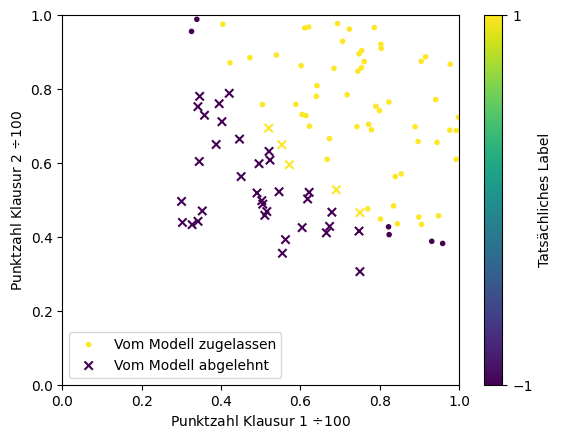

In [46]:
pred_greater_p3 = g(w_log, X) > 0.5

plt.scatter(X[pred_greater_p3, 1], X[pred_greater_p3, 2], c=y[pred_greater_p3], marker=".", label="Vom Modell zugelassen")
plt.scatter(X[~pred_greater_p3, 1], X[~pred_greater_p3, 2], c=y[~pred_greater_p3], marker="x", label="Vom Modell abgelehnt")
plt.xlabel("Punktzahl Klausur 1 $\\div 100$")
plt.ylabel("Punktzahl Klausur 2 $\\div 100$")
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.legend()
plt.colorbar(ticks=(1, -1), label="Tatsächliches Label")
plt.show()

(2) Schlagen Sie in den Vorlesungsfolien die Gleichung nach, die die Wahrscheinlichkeit $\mathbb{P}[y=+1|\mathbf{x}]$ mithilfe des Gewichtsvektors $\mathbf{w}$ modelliert. Das bedeutet: Schlagen Sie die Definition der logistischen Funktion $\theta(s)$ nach.

$$\theta(s)=\frac{1}{1+e^{-s}}$$

(3) Für welchen Wert $s$ gilt die Beziehung $\theta(s) \stackrel{!}{=} P_s = 0.5\;$?

$$\frac{1}{1+e^{-s}}=\frac12$$
$$\Leftrightarrow 1+e^{-s}=2$$
$$\Leftrightarrow e^{-s}=1$$
$$\Leftrightarrow -s=\ln (1)$$
$$\Leftrightarrow s=0$$

(4) Nutzen Sie die Beobachtung aus (3), um aus dem Gewichtsvektor $\mathbf{w}$ ihres logistischen Regressionsmodells eine Geradengleichung zu definieren. Zeichnen Sie diese "Entscheidungsgerade" in den Scatterplot aus Schritt (1) ein.

$$w_1 + x_1 \cdot w_2 + x_2 \cdot w_3 \overset{!}{=} 0$$
$$\Leftrightarrow x_2=\frac{-w_1 - x_1 \cdot w_2}{w_3}$$

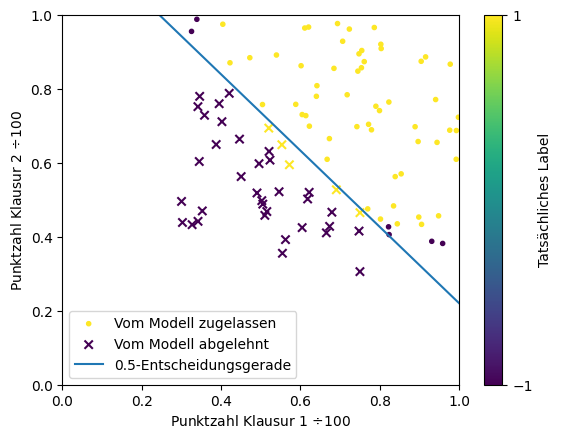

In [47]:
pred_greater_half = g(w_log, X) > 0.5

plt.scatter(X[pred_greater_half, 1], X[pred_greater_half, 2], c=y[pred_greater_half], marker=".", label="Vom Modell zugelassen")
plt.scatter(X[~pred_greater_half, 1], X[~pred_greater_half, 2], c=y[~pred_greater_half], marker="x", label="Vom Modell abgelehnt")
x_space = np.linspace(0, 1)
plt.plot(x_space, (-w_log[0] - x_space * w_log[1]) / w_log[2], label="0.5-Entscheidungsgerade")
plt.xlabel("Punktzahl Klausur 1 $\\div 100$")
plt.ylabel("Punktzahl Klausur 2 $\\div 100$")
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.legend()
plt.colorbar(ticks=(1, -1), label="Tatsächliches Label")


plt.show()

(5) **Optional:** Erzeugen Sie weitere Entscheidungsgeraden für die Schwellwerte $0.3$ und $0.8$ und zeichnen Sie sie ebenfalls farbkodiert in den Scatterplot von Schritt 1 ein. Was beobachten Sie? (1 Satz).

In [48]:
print(np.log(7.0/3.0))

0.8472978603872037


$$\frac{1}{1+e^{-s}}= \frac{3}{10}$$
$$\Leftrightarrow 1+e^{-s}=\frac{10}{3}$$
$$\Leftrightarrow e^{-s}=\frac{7}{3}$$
$$\Leftrightarrow -s=\ln (\frac{7}{3})$$
$$\Leftrightarrow s \approx -0.8473$$

$$w_1 + x_1 \cdot w_2 + x_2 \cdot w_3 \overset{!}{=} -0.8473$$
$$\Leftrightarrow x_2=-\frac{0.8473 + w_1 + x_1 \cdot w_2}{w_3}$$

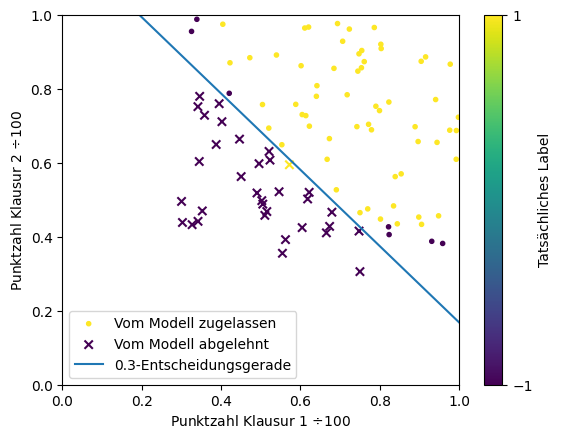

In [49]:
pred_greater_p3 = g(w_log, X) > 0.3

plt.scatter(X[pred_greater_p3, 1], X[pred_greater_p3, 2], c=y[pred_greater_p3], marker=".", label="Vom Modell zugelassen")
plt.scatter(X[~pred_greater_p3, 1], X[~pred_greater_p3, 2], c=y[~pred_greater_p3], marker="x", label="Vom Modell abgelehnt")
x_space = np.linspace(0, 1)
plt.plot(x_space, (-0.8473 - w_log[0] - x_space * w_log[1]) / w_log[2], label="0.3-Entscheidungsgerade")
plt.xlabel("Punktzahl Klausur 1 $\\div 100$")
plt.ylabel("Punktzahl Klausur 2 $\\div 100$")
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.legend()
plt.colorbar(ticks=(1, -1), label="Tatsächliches Label")


plt.show()

In [50]:
print(np.log(2.0/8.0))

-1.3862943611198906


$$\frac{1}{1+e^{-s}}= \frac{8}{10}$$
$$\Leftrightarrow 1+e^{-s}=\frac{10}{8}$$
$$\Leftrightarrow e^{-s}=\frac{2}{8}$$
$$\Leftrightarrow -s=\ln (\frac{2}{8})$$
$$\Leftrightarrow s \approx 1.3863$$

$$w_1 + x_1 \cdot w_2 + x_2 \cdot w_3 \overset{!}{=} 1.3863$$
$$\Leftrightarrow x_2=\frac{1.3863 - w_1 - x_1 \cdot w_2}{w_3}$$

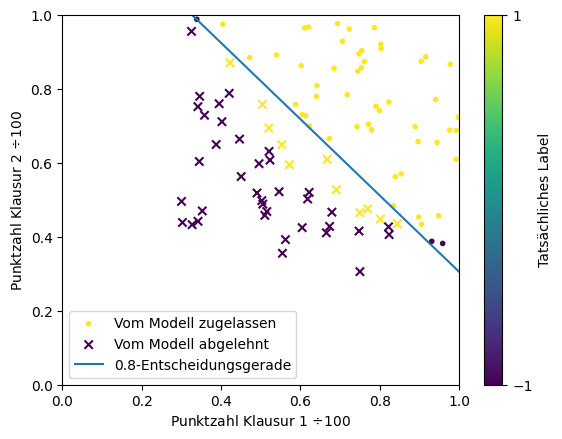

In [51]:
pred_greater_p3 = g(w_log, X) > 0.8

plt.scatter(X[pred_greater_p3, 1], X[pred_greater_p3, 2], c=y[pred_greater_p3], marker=".", label="Vom Modell zugelassen")
plt.scatter(X[~pred_greater_p3, 1], X[~pred_greater_p3, 2], c=y[~pred_greater_p3], marker="x", label="Vom Modell abgelehnt")
x_space = np.linspace(0, 1)
plt.plot(x_space, (1.3863 - w_log[0] - x_space * w_log[1]) / w_log[2], label="0.8-Entscheidungsgerade")
plt.xlabel("Punktzahl Klausur 1 $\\div 100$")
plt.ylabel("Punktzahl Klausur 2 $\\div 100$")
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.legend()
plt.colorbar(ticks=(1, -1), label="Tatsächliches Label")


plt.show()

(6) **Optional: interaktive Visualisierung**. Erzeugen Sie eine interaktive Visualisierung dafür, welche Bewerber/innen zum Studium zugelassen werden in Abhängigkeit der Wahl des Schwellwerts $P_s$. Betrachten Sie dazu noch einmal Schritt (1), bei dem Sie einen entsprechenden Scatterplot erzeugten. Erzeugen Sie nun mithilfe des [Interact-Widgets](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html) (der IPython Widgets) eine interaktive Abbildung, bei der Sie mithilfe eines `FloatSlider`s den Wert von $P_s$ auswählen können und Sie dadurch die Erzeugung einer Abbildung wie in Schritt (1) anstoßen.

In [52]:
def get_g(w, p=0.5):
    def g(x):
        return (-np.log((1.0/p)-1) - w[0] - x * w[1]) / w[2]
    return g

In [53]:

from ipywidgets import interact, FloatSlider
import matplotlib as mpl

def interactive_admissions(P_s=0.5):
    probs = g(w_log, X)
    accepted = probs >= P_s

    fig = plt.figure(figsize=(6,6))
    ax = fig.gca()
    cmap = 'bwr'
    sc1 = ax.scatter(X[accepted,1], X[accepted,2], c=y[accepted], cmap=cmap, vmin=-1, vmax=1, marker='.', label='Vom Modell zugelassen')
    sc2 = ax.scatter(X[~accepted,1], X[~accepted,2], c=y[~accepted], cmap=cmap, vmin=-1, vmax=1, marker='x', label='Vom Modell abgelehnt')

    x_space = np.linspace(0, 1, 300)
    boundary = get_g(w_log, P_s)
    ax.plot(x_space, boundary(x_space), color='k', lw=1.5, label=f'Entscheidungsgerade (P_s={P_s:.2f})')

    ax.set_xlabel("Punktzahl Klausur 1 $\\div 100$")
    ax.set_ylabel("Punktzahl Klausur 2 $\\div 100$")
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.legend(loc='upper left')

    m = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=-1, vmax=1))
    m.set_array([])
    fig.colorbar(m, ax=ax, ticks=[-1, 1], label='Tatsächliches Label')

    plt.tight_layout()
    plt.show()

# Interaktiver Slider für P_s
interact(interactive_admissions, P_s=FloatSlider(value=0.5, min=0.01, max=0.99, step=0.01, description='P_s'))

interactive(children=(FloatSlider(value=0.5, description='P_s', max=0.99, min=0.01, step=0.01), Output()), _do…

<function __main__.interactive_admissions(P_s=0.5)>

**Schlussbemerkung:** Durch die Umwandlung in ein Klassifikationsproblem lässt sich die Qualität des Modells anhand des Klassifikationsfehlers evaluieren. Sie ahnen vermutlich bereits, wie dies funktionieren könnte: Sie würden ein Trainingsset und ein Testset definieren, auf dem Trainingsset das logistische Regressionsmodell trainieren, einen Schwellwert $P_s$ definieren, und den Klassifikationsfehler (wie Sie ihn aus früheren Übungen kennen) auf dem Testset berechnen. Dieser ist nun abhängig von der Wahl des Schwellwerts $P_s$.

### 7.3 Klassifikation durch Regression oder logistische Regression

In dieser Übung wollen wir die Verwandtschaft zwischen Klassifikation, Regression und logistischer Regression weiter untersuchen. Wir betrachten die punktweisen Fehler für die linearen Modelle der Klassifikation, linearen Regression und der logistischen Regression,

$$e_\text{class}(s,y) = [\![ y \neq \text{sign}(s) ]\!]$$
$$e_\text{lin}(s,y) = (y-s)^2$$
$$e_\text{log}(s,y) = \ln (1+e^{-ys}) $$

wobei $s=\mathbf{w}^\text{T}\mathbf{x}$ das in der Vorlesung vorstellte "Signal" bezeichnet und $y$ das Target(-Label).

**Ihre Aufgaben**

(1) Erzeugen Sie eine Abbildung (einen Plot), der $e_\text{class}, e_\text{lin}$ und $e_\text{log}$ für $y=1$ in Abhängigkeit des Signals $s$ (x-Achse) darstellt. Der x-Achsenbereich gehe von -1 bis 1. Der y-Achsenbereich gehe von 0 bis 5.

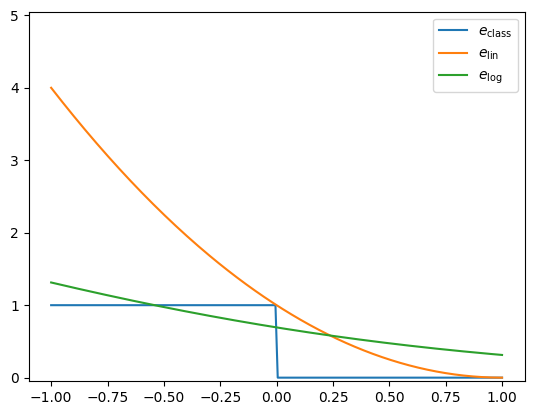

In [ ]:
y = 1
x_space = np.linspace(-1, 1, 200)
plt.plot(x_space, (np.sign(x_space) != y), label="$e_\\text{class}$")
plt.plot(x_space, (y - x_space) ** 2, label="$e_\\text{lin}$")
plt.plot(x_space, np.log(1 + np.exp(-y * x_space)), label="$e_\\text{log}$")
plt.ylim((-0.05, 5.05))
plt.legend()
plt.show()

(2) Zeigen Sie, dass folgende Schranke gilt: $e_\text{class}(s,y) \leq e_\text{lin}(s,y)$. Der Klassifikationsfehler ist also durch den Fehler der linearen Regression beschränkt.

**Beweis durch Widerspruch**

Das Maximum von $e_\text{class}$ ist 1.

Wir suchen also für einen Gegenbeweis ein $s_0$ für das gilt: $e_\text{class}(s_0,y)=1$ und $e_\text{lin}(s_0,y)<1$

$$e_\text{lin}(s_0,y)<1$$
$$\Leftrightarrow (y-s_0)^2<1$$
$$\Leftrightarrow \pm (y-s_0)<1$$
$$\Leftrightarrow y-s_0<1 \lor -y+s_0<1$$
$$\Leftrightarrow y-1<s_0 \lor s_0<1+y$$
$$\Leftrightarrow y-1<s_0 <1+y$$
$$\begin{array}{cccc}
-2<s_0 <0, & \text{Für } y=-1 & \text{sign}(s_0)=-1 && \text{Und somit } e_\text{class}=0\\
0<s_0 <2, & \text{Für } y=1 & \text{sign}(s_0)=1 && \text{Und somit } e_\text{class}=0
\end{array}
$$

So ein $s_0$ gibt es also nicht (*Widerspruch*)

Zusammen mit der Gegebenheit, dass $e_\text{lin}(s,y) \geq 0$ für alle $s$ ist, ist damit gezeigt, dass es kein $s_0$ gibt, für dass gilt $e_\text{lin}(s_0,y)<e_\text{class}(s_0,y)$ und somit gelten muss:
$$e_\text{class}(s,y) \leq e_\text{lin}(s,y)$$
*qed*

(3) Zeigen Sie, dass folgende Schranke gilt: $e_\text{class}(s,y) \leq \frac{1}{\ln(2)}e_\text{log}(s,y)$. Der Klassifikationsfehler ist also durch den Fehler der logistischen Regression beschränkt.

**Erneut Widerspruchsbeweis**

Wir suchen also für einen Gegenbeweis ein $s_0$ für das gilt: $e_\text{class}(s_0,y)=1$ und $\frac{1}{\ln (2)} e_\text{log}(s_0,y)<1$

$$\frac{1}{\ln (2)} e_\text{log}(s_0,y)<1$$
$$\Leftrightarrow \frac{1}{\ln (2)} \ln (1+e^{-ys_0})<1$$
$$\Leftrightarrow \ln (1+e^{-ys_0})<\ln (2)$$
$$\Leftrightarrow 1+e^{-ys_0}<2$$
$$\Leftrightarrow e^{-ys_0}<1$$
$$\Leftrightarrow -ys_0<0$$
$$\begin{array}{cccc}
s_0 < 0, & \text{Für } y=-1 & \text{sign}(s_0)=-1 && \text{Und somit } e_\text{class}=0\\
-s_0 < 0 \Leftrightarrow s_0 > 0, & \text{Für } y=1 & \text{sign}(s_0)=1 && \text{Und somit } e_\text{class}=0
\end{array}
$$

So ein $s_0$ gibt es also nicht (*Widerspruch*)

Zusammen mit der Gegebenheit, dass $\frac{1}{\ln (2)} e_\text{log}(s,y) \geq 0$ für alle $s$ ist, ist damit gezeigt, dass es kein $s_0$ gibt, für dass gilt $\frac{1}{\ln (2)} e_\text{log}(s_0,y)<e_\text{class}(s_0,y)$ und somit gelten muss:
$$e_\text{class}(s,y) \leq \frac{1}{\ln (2)} e_\text{log}(s,y)$$
*qed*

**Hinweise**
* Ich erwarte von Ihnen keine langen Beweise. 1-3 Sätze für Aufgabe 2 und 1-3 Sätze für Aufgabe 3 reichen völlig aus. Betrachten Sie, wie sich die Fehler mit wachsendem $s$ verändern und betrachten Sie verschiedene Bereiche für $s$, insbesondere das Verhalten bei $s\leq 0$, $s=0$ und $s>0$.

**Interpretation**: Wenn wir eine Regression oder logistische Regression durchführen, werden die entsprechenden Fehler kleiner und damit auch die Schranken für den Klassifikationsfehler:
* Dies ist auch eine Motivation dafür, dass wir lineare Regression oder logistische Regression für Klassifikationsprobleme einsetzen können.
* Die aus einer Regression oder logistischen Regression gewonnenen Gewichtsvektoren werden gerne als Ausgangspunkt für den Perzeptron-Lern-Algorithmus genutzt. Die obigen Schranken motivieren so ein Vorgehen: Da die Minimierung des Klassifikationsfehlers ein nicht-triviales kombinatorisches Optimierungsproblem darstellt, ist die direkte Minimierung über PLA schwierig. Mit den Gewichten aus der linearen Regression oder logistischen Regression können wir PLA aber einen guten "Start" verschaffen, weil wir in einer Gegend des Lösungsraums starten, wo schon kleine Klassifikationsfehler vorliegen.

### 7.4 PLA und der stochastische Gradientenabstieg
In dieser Übung wollen wir Zusammenhänge zwischen den Algorithmen "PLA" und dem "stochastischen Gradientenabstieg" untersuchen.

**Ihre Aufgaben**

(1) Wir definieren einen punktweisen Fehler wie folgt:
$$\text{e}_n(\mathbf{w}) = \max(0,-y_n\mathbf{w}^\text{T}\mathbf{x}_n)$$
Betrachten Sie diesen Fehler für einen Datenpunkt $(\mathbf{x}_n,y_n)$. Argumentieren Sie, dass PLA so vorgeht wie der stochastische Gradientenabstieg auf dem oben definierten Fehler.
  * Hinweise: Schlagen Sie in den Folien nochmal das Gewichtsupdate und das Kriterium nach, nach denen PLA ein Gewichtsupdate durchführt. Schlagen Sie ebenfalls in den Folien nach, wie der stochastische Gradientenabstieg ein Gewichtsupdate durchführt. Betrachten Sie die beiden Fälle, dass (a) ein Gewichtsupdate durchgeführt oder (b) nicht durchgeführt wird.

PLA sucht sich ein zufälliges Datenpaar $(x_n, y_n)$, das falsch klassifiziert wurde und führt damit ein Gewichtsupdate durch. Der stochastische Gradientenabstieg sucht sich ebenfalls nur den Fehler eines Datenpaares aus und führt ein Gewichtsupdate in negative Gradientenrichtung durch.

(2) Betrachten Sie die logistische Regression und den Fall eines extrem großen Gewichtsvektors $\mathbf{w}$. Argumentieren Sie, dass die Minimierung von $E_\text{in}$ der logistischen Regression mittels stochastischem Gradientenabstiegs sehr ähnlich zu PLA ist.
  * Hinweise: Betrachten Sie den punktweisen Gradienten der logistischen Regression und überlegen Sie sich, wie sich dieser verändert in Anbetracht der zwei Fälle (a) und (b). Nutzen Sie aus, dass $\mathbf{w}$ ein großer Gewichtsvektor ist.